# Last trained PPO vs zero-action vs combined heuristic

Compares the most recently trained upper-agent PPO checkpoint
(`models/upper_ppo_mixed_only_fixed_reward_10k/run_20260706_212506/upper_ppo_final.zip`)
against two reference controllers, across all 8 controllable scenarios:

- **Zero action (no action)** -- A3 offset bias held at 0 every step (no intelligent layer).
- **Combined heuristic (upper+lower)** -- rule-based `compute_upper_expert_directional_bias`
  upper expert executed through the strong directional lower-agent heuristic executor.
- **Trained PPO** -- the learned upper-agent policy (deterministic actions), trained only on
  the `jain_control_mixed` scenario for 10k timesteps.

Expectation going in: since the PPO model was only trained on one scenario and only for
10k steps, we expect it to land **between** the no-action baseline and the hand-tuned
combined heuristic on most QoS/load metrics -- better than doing nothing, not yet matching
a mature rule-based controller.

In [1]:
import os
from pathlib import Path

if not Path('results').exists():
    os.chdir(Path.cwd().parent)

import glob
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 220)

RESULT_DIRS = {
    'Zero action (no action)': ('results/last_model_comparison/zero_action', '*_zero_action_trace.csv'),
    'Combined heuristic (upper+lower)': ('results/last_model_comparison/combined_heuristic', '*_heuristic_trace.csv'),
    'Trained PPO (last model)': ('results/last_model_comparison/trained_model', '*_trained_policy_trace.csv'),
}
CONTROLLER_ORDER = list(RESULT_DIRS.keys())
CONTROLLER_COLORS = {
    'Zero action (no action)': '#4c78a8',
    'Combined heuristic (upper+lower)': '#f58518',
    'Trained PPO (last model)': '#54a24b',
}
GNBS = [0, 1, 2]
SLICES = ['eMBB', 'URLLC', 'mMTC']
OUT_DIR = Path('results/last_model_comparison')
OUT_DIR.mkdir(parents=True, exist_ok=True)

frames = []
for controller, (dir_path, pattern) in RESULT_DIRS.items():
    for f in sorted(glob.glob(str(Path(dir_path) / pattern))):
        df = pd.read_csv(f)
        df['controller'] = controller
        df['trace_file'] = f
        frames.append(df)

trace = pd.concat(frames, ignore_index=True)
SCENARIOS = sorted(trace['scenario_name'].unique())
print('Scenarios:', SCENARIOS)
display(trace.groupby('controller').size().rename('rows'))

Scenarios: ['jain_balance_controllable', 'jain_control_embb_mmtc', 'jain_control_embb_urllc', 'jain_control_mixed', 'jain_control_mmtc', 'jain_control_outer_congested', 'jain_control_urllc', 'jain_control_urllc_mmtc']


/tmp/ipykernel_1477216/3887647884.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['controller'] = controller
/tmp/ipykernel_1477216/3887647884.py:39: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['trace_file'] = f


controller
Combined heuristic (upper+lower)    80
Trained PPO (last model)            80
Zero action (no action)             80
Name: rows, dtype: int64

In [2]:
MODEL_RUN_DIR = Path('models/upper_ppo_mixed_only_fixed_reward_10k/run_20260706_212506')
MODEL_PATH = MODEL_RUN_DIR / 'upper_ppo_final.zip'
config = json.loads((MODEL_RUN_DIR / 'config.json').read_text())

print('Model checkpoint:', MODEL_PATH)
print('Trained only on scenario:', config.get('single_training_scenario'))
print('Total timesteps:', config.get('total_timesteps'))
print('Evaluated on', len(SCENARIOS), 'controllable scenarios,',
      trace.groupby('controller')['episode'].nunique().max(), 'episodes-ish per scenario/controller')

Model checkpoint: models/upper_ppo_mixed_only_fixed_reward_10k/run_20260706_212506/upper_ppo_final.zip
Trained only on scenario: jain_control_mixed
Total timesteps: 10000
Evaluated on 8 controllable scenarios, 10 episodes-ish per scenario/controller


## 1. Scenario-level QoS / load-balance summary

In [3]:
summary_cols = ['reward', 'handover_count', 'network_throughput_mbps', 'network_delivery_ratio',
                'jain_fairness_raw', 'sla_severity', 'sla_count', 'paper_demand_load_std',
                'paper_excess_load_mean', 'network_mean_hol_delay_ms', 'network_queue_kbits',
                'network_drop_ratio']
summary_cols = [c for c in summary_cols if c in trace.columns]

scenario_summary = (
    trace.groupby(['scenario_name', 'controller'])[summary_cols]
    .mean()
    .reset_index()
)
scenario_summary_path = OUT_DIR / 'scenario_summary.csv'
scenario_summary.to_csv(scenario_summary_path, index=False)
print('Saved:', scenario_summary_path)
display(scenario_summary.round(4))

Saved: results/last_model_comparison/scenario_summary.csv


,scenario_name,controller,reward,handover_count,network_throughput_mbps,network_delivery_ratio,jain_fairness_raw,sla_severity,sla_count,paper_demand_load_std,paper_excess_load_mean,network_mean_hol_delay_ms,network_queue_kbits,network_drop_ratio
0,jain_balance_controllable,Combined heuristic (upper+lower),-0.7736,4.0,74.1530,0.9998,0.9968,0.0000,0.0,0.0000,0.0000,0.1333,15.9452,0.0
1,jain_balance_controllable,Trained PPO (last model),-0.1183,4.0,73.8885,0.9999,0.9951,0.0000,0.0,0.0000,0.0000,0.0500,7.4086,0.0
2,jain_balance_controllable,Zero action (no action),-1.0985,0.0,61.3543,0.9944,0.3333,0.0000,0.0,0.4243,0.0833,5.0833,348.6226,0.0
3,jain_control_embb_mmtc,Combined heuristic (upper+lower),-0.7611,8.0,72.1647,0.9998,0.9970,0.0000,0.0,0.0125,0.0000,0.1000,11.9053,0.0
4,jain_control_embb_mmtc,Trained PPO (last model),-0.3681,6.0,72.1698,0.9999,0.8933,0.0000,0.0,0.0903,0.0000,0.0500,8.8580,0.0
5,jain_control_embb_mmtc,Zero action (no action),-0.9042,0.0,51.7084,0.9998,0.3333,0.0000,0.0,0.3771,0.0500,0.1167,11.4355,0.0
6,jain_control_embb_urllc,Combined heuristic (upper+lower),-0.7504,8.0,65.9542,0.9998,0.9962,0.0000,0.0,0.0125,0.0000,0.0667,10.1855,0.0
7,jain_control_embb_urllc,Trained PPO (last model),-0.1152,8.0,70.9582,0.9999,0.9972,0.0000,0.0,0.0125,0.0000,0.1000,9.7849,0.0
8,jain_control_embb_urllc,Zero action (no action),-0.9042,0.0,47.2387,0.9985,0.3333,0.0005,0.0,0.3771,0.0500,0.9250,70.2795,0.0
9,jain_control_mixed,Combined heuristic (upper+lower),-0.6667,12.0,98.8305,0.9999,0.9969,0.0000,0.0,0.0000,0.0000,0.0722,11.5136,0.0


## 2. Network QoS / load-balance -- grouped bars across all scenarios

Saved: results/last_model_comparison/network_qos_comparison_all_scenarios.png


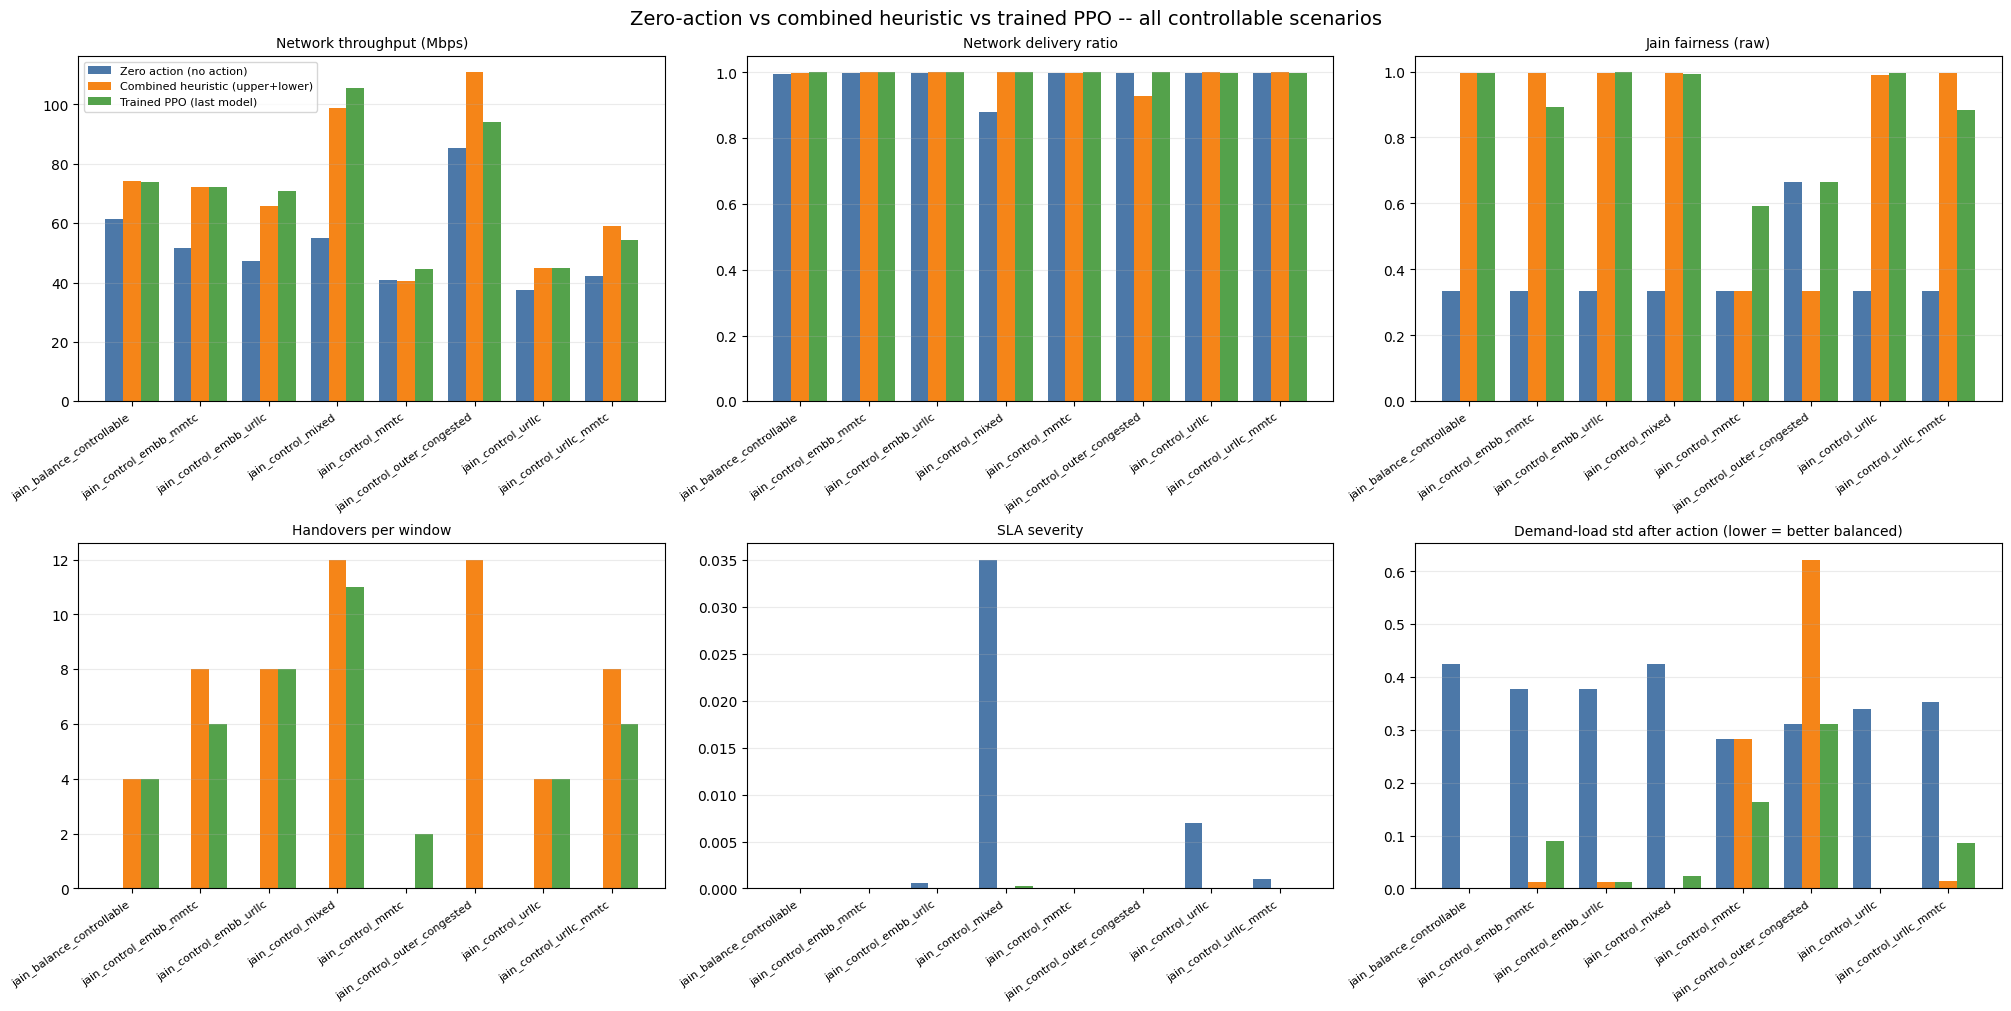

In [4]:
x = np.arange(len(SCENARIOS))
width = 0.26
metrics = [
    ('network_throughput_mbps', 'Network throughput (Mbps)', None),
    ('network_delivery_ratio', 'Network delivery ratio', (0, 1.05)),
    ('jain_fairness_raw', 'Jain fairness (raw)', None),
    ('handover_count', 'Handovers per window', None),
    ('sla_severity', 'SLA severity', None),
    ('paper_demand_load_std', 'Demand-load std after action (lower = better balanced)', None),
]
metrics = [(c, t, y) for c, t, y in metrics if c in scenario_summary.columns]

fig, axes = plt.subplots(2, 3, figsize=(20, 10), constrained_layout=True)
axes = axes.ravel()
for ax, (metric, title, ylim) in zip(axes, metrics):
    for i, controller in enumerate(CONTROLLER_ORDER):
        vals = []
        for scenario in SCENARIOS:
            row = scenario_summary[(scenario_summary['scenario_name'] == scenario) & (scenario_summary['controller'] == controller)]
            vals.append(float(row[metric].iloc[0]) if len(row) else np.nan)
        ax.bar(x + (i - 1) * width, vals, width, label=controller, color=CONTROLLER_COLORS[controller])
    ax.set_title(title, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(SCENARIOS, rotation=35, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.25)
    if ylim is not None:
        ax.set_ylim(*ylim)
axes[0].legend(fontsize=8, loc='best')
fig.suptitle('Zero-action vs combined heuristic vs trained PPO -- all controllable scenarios', fontsize=14)
out_path = OUT_DIR / 'network_qos_comparison_all_scenarios.png'
plt.savefig(out_path, dpi=160, bbox_inches='tight')
print('Saved:', out_path)
plt.show()

## 3. Sanity check -- does the trained PPO land *between* zero-action and the combined heuristic?

In [5]:
def is_between(value, a, b):
    lo, hi = (a, b) if a <= b else (b, a)
    return lo <= value <= hi

check_metrics = [c for c, _, _ in metrics]
rows = []
for scenario in SCENARIOS:
    for metric in check_metrics:
        vals = {}
        for controller in CONTROLLER_ORDER:
            row = scenario_summary[(scenario_summary['scenario_name'] == scenario) & (scenario_summary['controller'] == controller)]
            vals[controller] = float(row[metric].iloc[0]) if len(row) else np.nan
        zero_v = vals['Zero action (no action)']
        heur_v = vals['Combined heuristic (upper+lower)']
        ppo_v = vals['Trained PPO (last model)']
        between = (
            is_between(ppo_v, zero_v, heur_v)
            if np.isfinite(zero_v) and np.isfinite(heur_v) and np.isfinite(ppo_v)
            else np.nan
        )
        rows.append({
            'scenario': scenario, 'metric': metric,
            'zero_action': zero_v, 'combined_heuristic': heur_v, 'trained_ppo': ppo_v,
            'ppo_between_zero_and_heuristic': between,
        })

between_df = pd.DataFrame(rows)
between_path = OUT_DIR / 'ppo_between_check.csv'
between_df.to_csv(between_path, index=False)

share = between_df['ppo_between_zero_and_heuristic'].mean()
print(f'Trained PPO landed between zero-action and the combined heuristic in {share:.0%} '
      f'of scenario x metric combinations ({int(between_df["ppo_between_zero_and_heuristic"].sum())}/{len(between_df)}).')
print('Recall the model was trained on jain_control_mixed only -- expect it to hold up best there')
print('and generalize less cleanly on scenarios it never saw during training.')
display(between_df.round(4))

Trained PPO landed between zero-action and the combined heuristic in 71% of scenario x metric combinations (34/48).
Recall the model was trained on jain_control_mixed only -- expect it to hold up best there
and generalize less cleanly on scenarios it never saw during training.


,scenario,metric,zero_action,combined_heuristic,trained_ppo,ppo_between_zero_and_heuristic
0,jain_balance_controllable,network_throughput_mbps,61.3543,74.1530,73.8885,True
1,jain_balance_controllable,network_delivery_ratio,0.9944,0.9998,0.9999,False
2,jain_balance_controllable,jain_fairness_raw,0.3333,0.9968,0.9951,True
3,jain_balance_controllable,handover_count,0.0000,4.0000,4.0000,True
4,jain_balance_controllable,sla_severity,0.0000,0.0000,0.0000,True
5,jain_balance_controllable,paper_demand_load_std,0.4243,0.0000,0.0000,True
6,jain_control_embb_mmtc,network_throughput_mbps,51.7084,72.1647,72.1698,False
7,jain_control_embb_mmtc,network_delivery_ratio,0.9998,0.9998,0.9999,False
8,jain_control_embb_mmtc,jain_fairness_raw,0.3333,0.9970,0.8933,True
9,jain_control_embb_mmtc,handover_count,0.0000,8.0000,6.0000,True


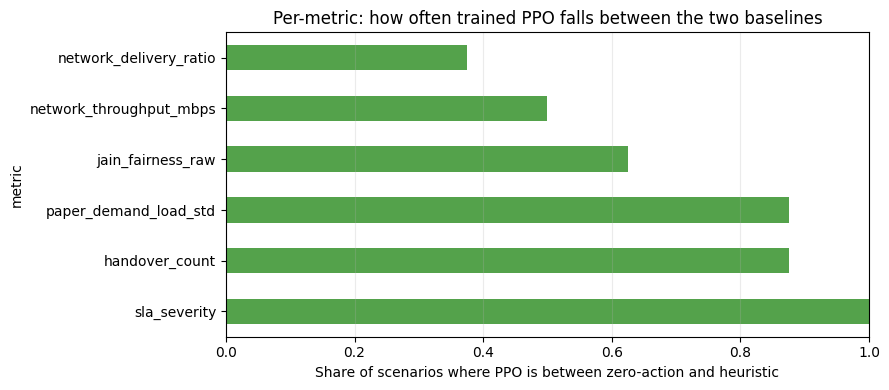

In [6]:
per_metric = between_df.groupby('metric')['ppo_between_zero_and_heuristic'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
per_metric.plot(kind='barh', ax=ax, color='#54a24b')
ax.set_xlim(0, 1)
ax.set_xlabel('Share of scenarios where PPO is between zero-action and heuristic')
ax.set_title('Per-metric: how often trained PPO falls between the two baselines')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Load plot -- network PRB demand/used before vs after action, per scenario

Saved: results/last_model_comparison/network_load_before_after_all_scenarios.png


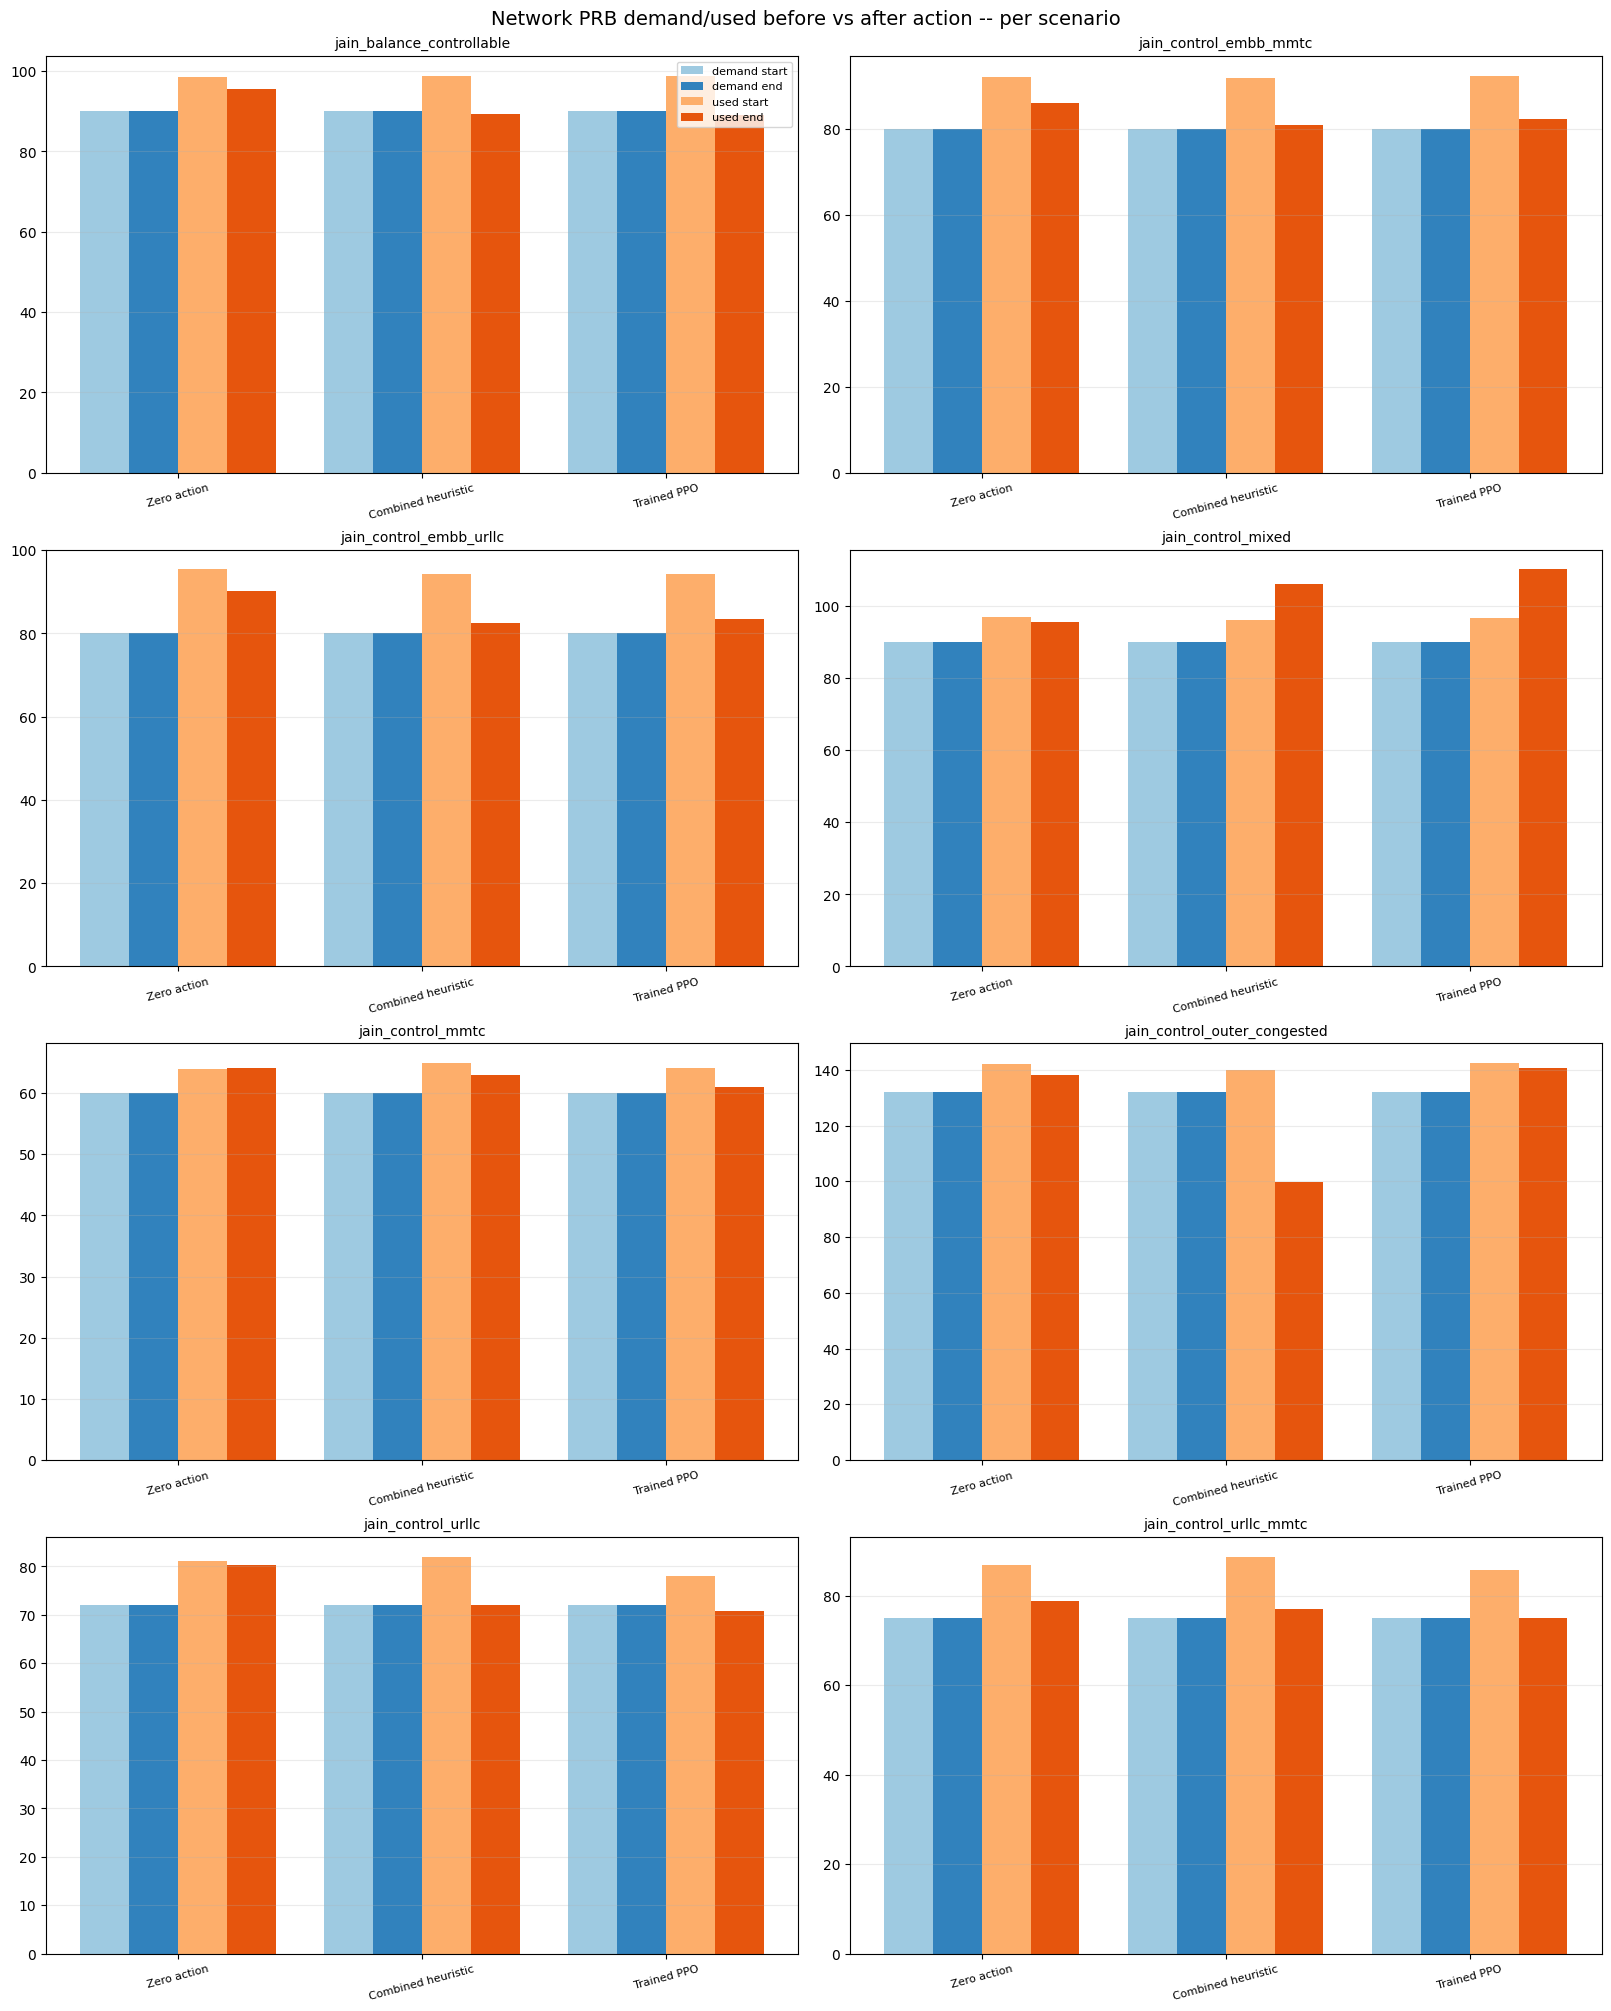

In [7]:
network_load_cols = ['network_demand_prb_start', 'network_demand_prb_end',
                     'network_used_prb_start', 'network_used_prb_end']
load_summary = trace.groupby(['scenario_name', 'controller'])[network_load_cols].mean().reset_index()
load_summary.to_csv(OUT_DIR / 'network_load_before_after_summary.csv', index=False)

fig, axes = plt.subplots(4, 2, figsize=(16, 20), constrained_layout=True)
axes = axes.ravel()
w = 0.2
x = np.arange(len(CONTROLLER_ORDER))
for ax, scenario in zip(axes, SCENARIOS):
    sub = load_summary[load_summary['scenario_name'] == scenario]
    demand_start = [sub[sub['controller'] == c]['network_demand_prb_start'].iloc[0] for c in CONTROLLER_ORDER]
    demand_end = [sub[sub['controller'] == c]['network_demand_prb_end'].iloc[0] for c in CONTROLLER_ORDER]
    used_start = [sub[sub['controller'] == c]['network_used_prb_start'].iloc[0] for c in CONTROLLER_ORDER]
    used_end = [sub[sub['controller'] == c]['network_used_prb_end'].iloc[0] for c in CONTROLLER_ORDER]
    ax.bar(x - 1.5 * w, demand_start, w, label='demand start', color='#9ecae1')
    ax.bar(x - 0.5 * w, demand_end, w, label='demand end', color='#3182bd')
    ax.bar(x + 0.5 * w, used_start, w, label='used start', color='#fdae6b')
    ax.bar(x + 1.5 * w, used_end, w, label='used end', color='#e6550d')
    ax.set_title(scenario, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([c.split(' (')[0] for c in CONTROLLER_ORDER], rotation=15, fontsize=8)
    ax.grid(axis='y', alpha=0.25)
for ax in axes[len(SCENARIOS):]:
    ax.axis('off')
axes[0].legend(fontsize=8)
fig.suptitle('Network PRB demand/used before vs after action -- per scenario', fontsize=14)
out_path = OUT_DIR / 'network_load_before_after_all_scenarios.png'
plt.savefig(out_path, dpi=160, bbox_inches='tight')
print('Saved:', out_path)
plt.show()

## 5. Load-balance quality -- end-of-window load std across gNBs

Saved: results/last_model_comparison/load_balance_std_all_scenarios.png


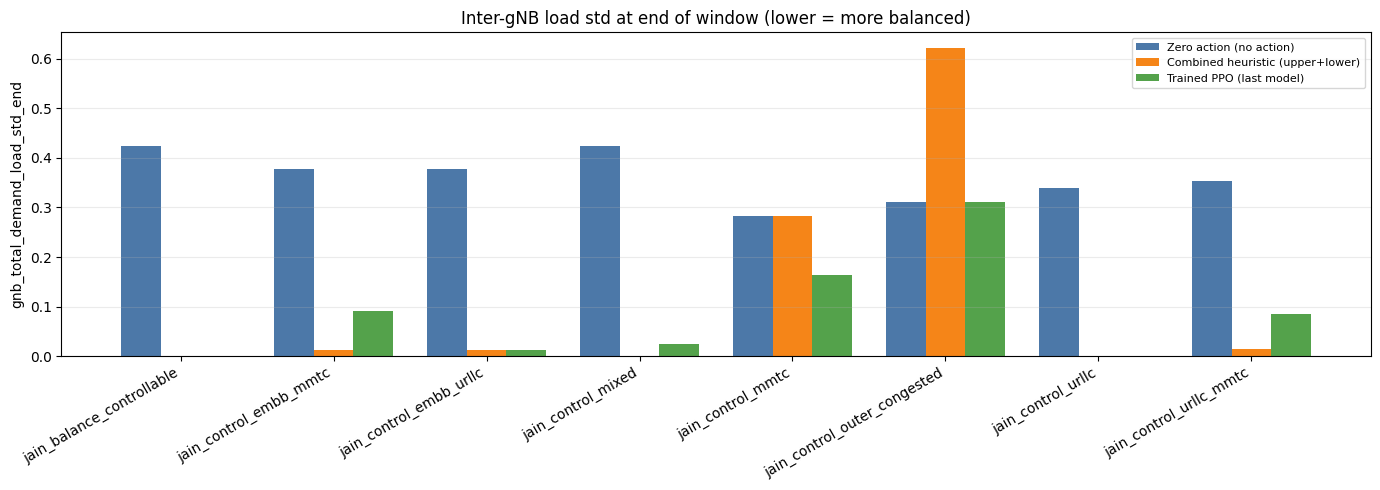

In [8]:
balance_col = 'gnb_total_demand_load_std_end' if 'gnb_total_demand_load_std_end' in trace.columns else 'paper_demand_load_std'
balance_summary = trace.groupby(['scenario_name', 'controller'])[balance_col].mean().reset_index()

x = np.arange(len(SCENARIOS))
width = 0.26
fig, ax = plt.subplots(figsize=(14, 5))
for i, controller in enumerate(CONTROLLER_ORDER):
    vals = []
    for scenario in SCENARIOS:
        row = balance_summary[(balance_summary['scenario_name'] == scenario) & (balance_summary['controller'] == controller)]
        vals.append(float(row[balance_col].iloc[0]) if len(row) else np.nan)
    ax.bar(x + (i - 1) * width, vals, width, label=controller, color=CONTROLLER_COLORS[controller])
ax.set_xticks(x)
ax.set_xticklabels(SCENARIOS, rotation=30, ha='right')
ax.set_ylabel(balance_col)
ax.set_title('Inter-gNB load std at end of window (lower = more balanced)')
ax.grid(axis='y', alpha=0.25)
ax.legend(fontsize=8)
out_path = OUT_DIR / 'load_balance_std_all_scenarios.png'
plt.tight_layout()
plt.savefig(out_path, dpi=160, bbox_inches='tight')
print('Saved:', out_path)
plt.show()

## 6. Per-gNB load across scenarios

Saved: results/last_model_comparison/per_gnb_load_all_scenarios.png


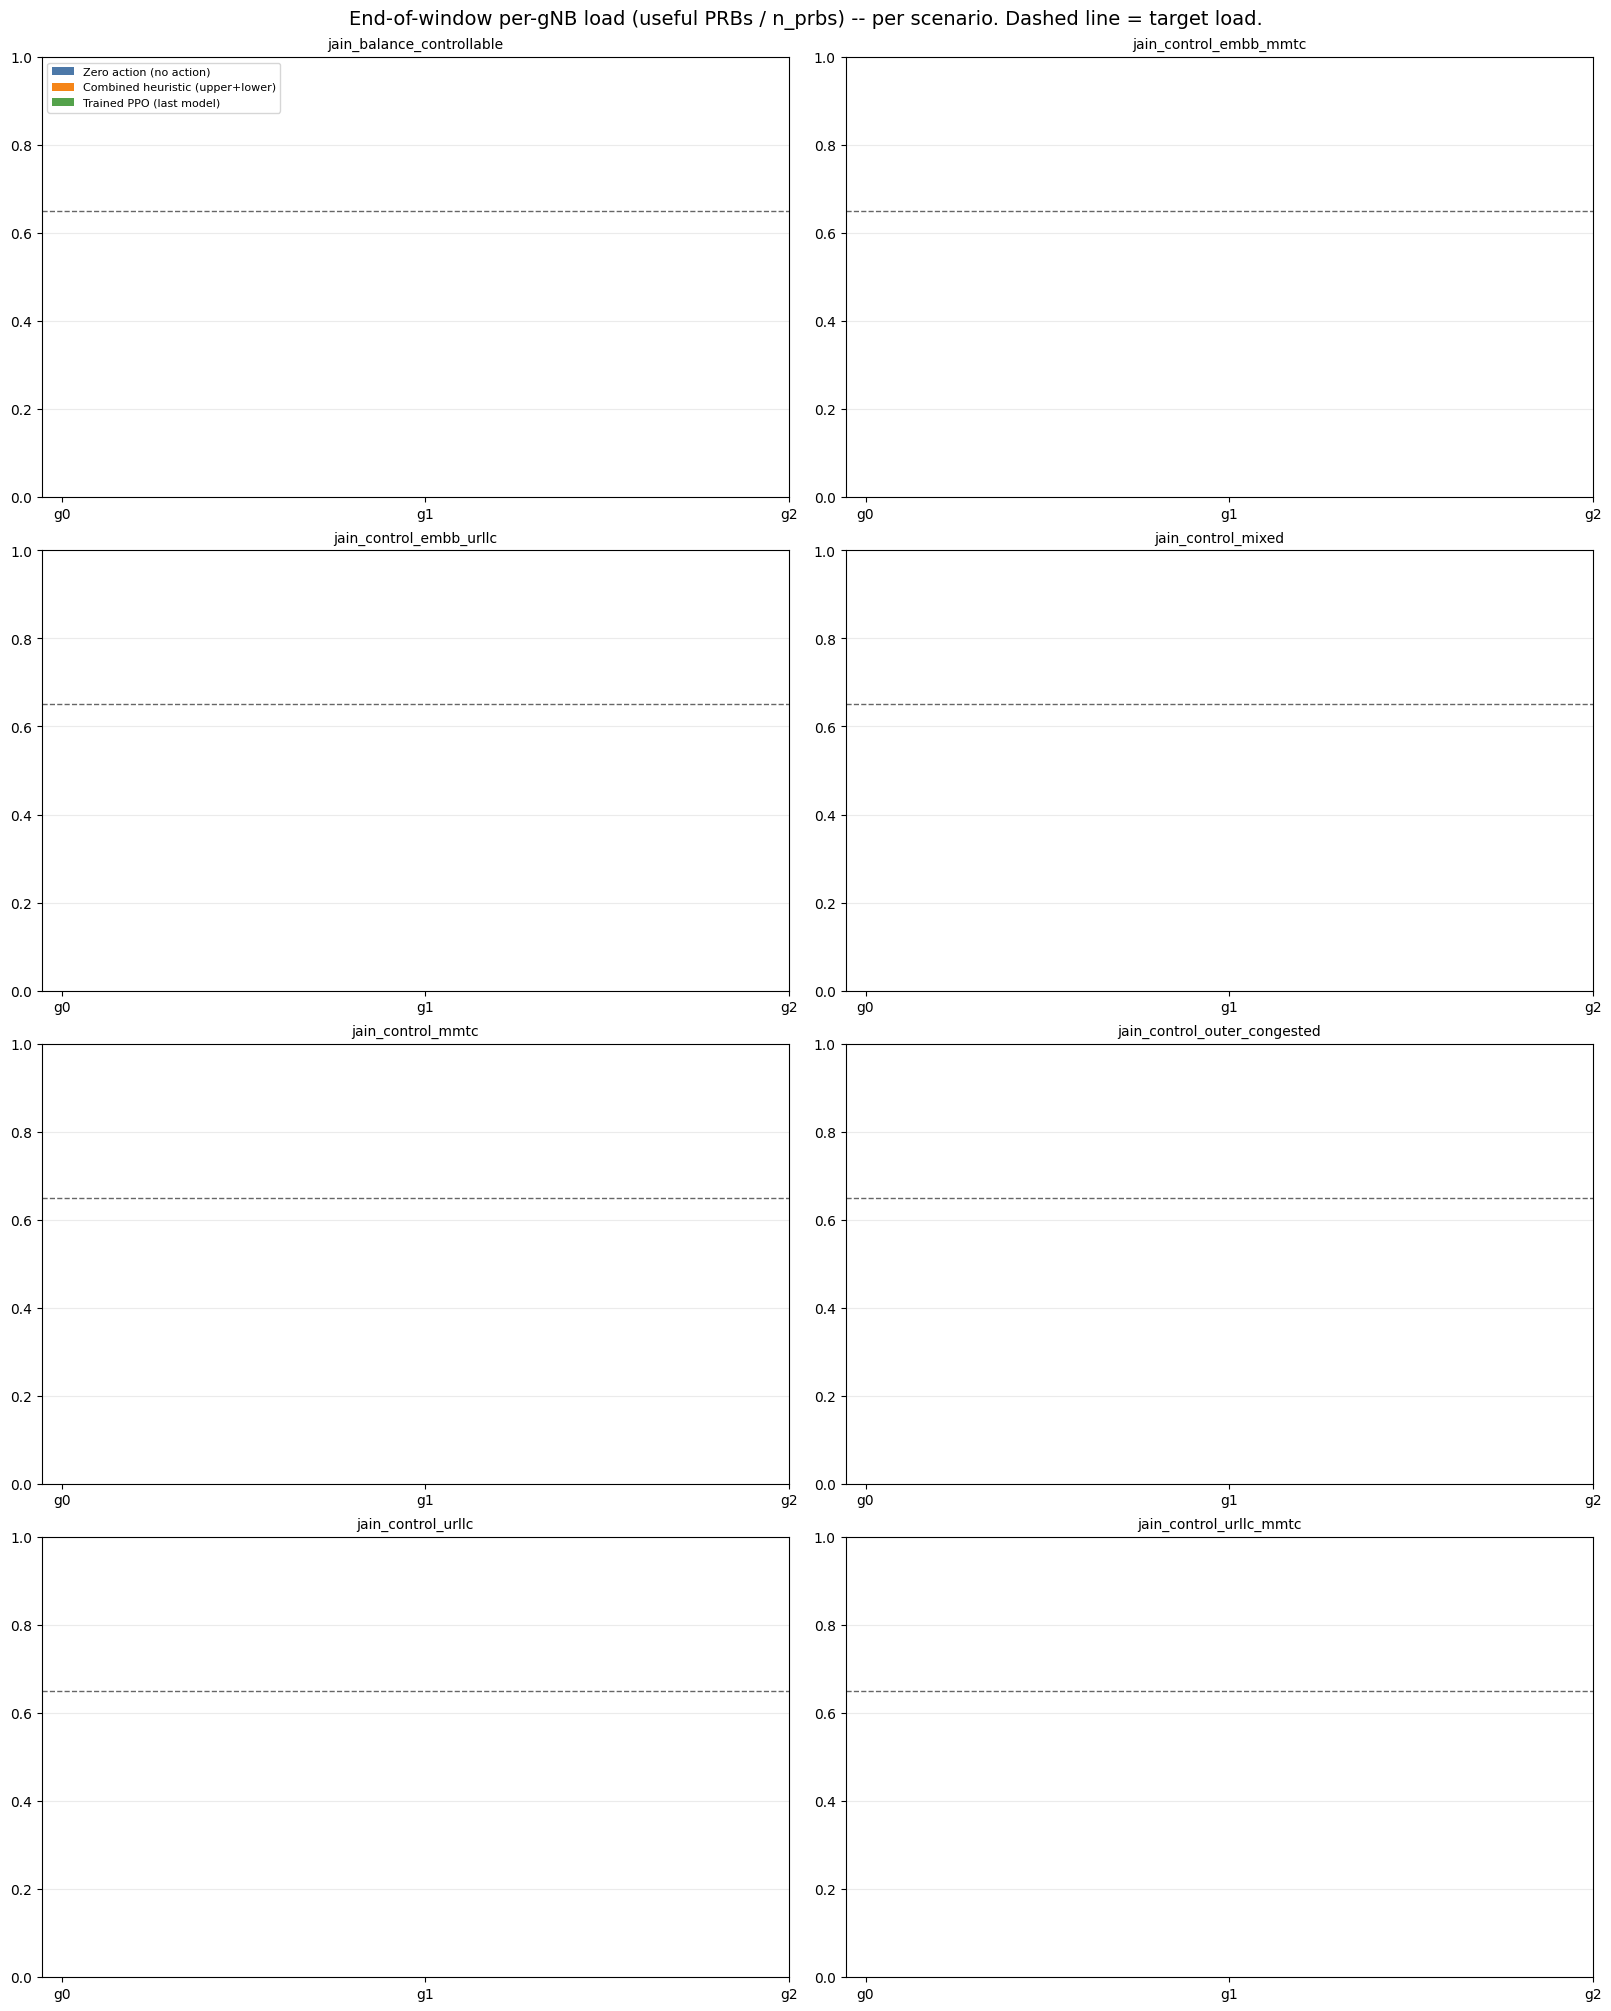

In [9]:
gnb_load_cols = [f'gnb_total_useful_load_end_g{g}' for g in GNBS]
gnb_load_cols = [c for c in gnb_load_cols if c in trace.columns]
gnb_load_summary = trace.groupby(['scenario_name', 'controller'])[gnb_load_cols].mean().reset_index()
gnb_load_summary.to_csv(OUT_DIR / 'per_gnb_load_summary.csv', index=False)

fig, axes = plt.subplots(4, 2, figsize=(16, 20), constrained_layout=True)
axes = axes.ravel()
x = np.arange(len(GNBS))
width = 0.26
target_load = config.get('gnb_load_target', 0.65)
for ax, scenario in zip(axes, SCENARIOS):
    sub = gnb_load_summary[gnb_load_summary['scenario_name'] == scenario]
    for i, controller in enumerate(CONTROLLER_ORDER):
        row = sub[sub['controller'] == controller]
        vals = [float(row[c].iloc[0]) if len(row) else np.nan for c in gnb_load_cols]
        ax.bar(x + (i - 1) * width, vals, width, label=controller, color=CONTROLLER_COLORS[controller])
    ax.axhline(target_load, color='black', ls='--', lw=1, alpha=0.6)
    ax.set_title(scenario, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([f'g{g}' for g in GNBS])
    y_max = max(1.0, float(sub[gnb_load_cols].max().max()) * 1.1) if len(sub) else 1.0
    ax.set_ylim(0, y_max)
    ax.grid(axis='y', alpha=0.25)
for ax in axes[len(SCENARIOS):]:
    ax.axis('off')
axes[0].legend(fontsize=8)
fig.suptitle('End-of-window per-gNB load (useful PRBs / n_prbs) -- per scenario. Dashed line = target load.', fontsize=14)
out_path = OUT_DIR / 'per_gnb_load_all_scenarios.png'
plt.savefig(out_path, dpi=160, bbox_inches='tight')
print('Saved:', out_path)
plt.show()

## 7. Per-slice load on each gNB

Saved: results/last_model_comparison/per_gnb_per_slice_load_all_scenarios.png


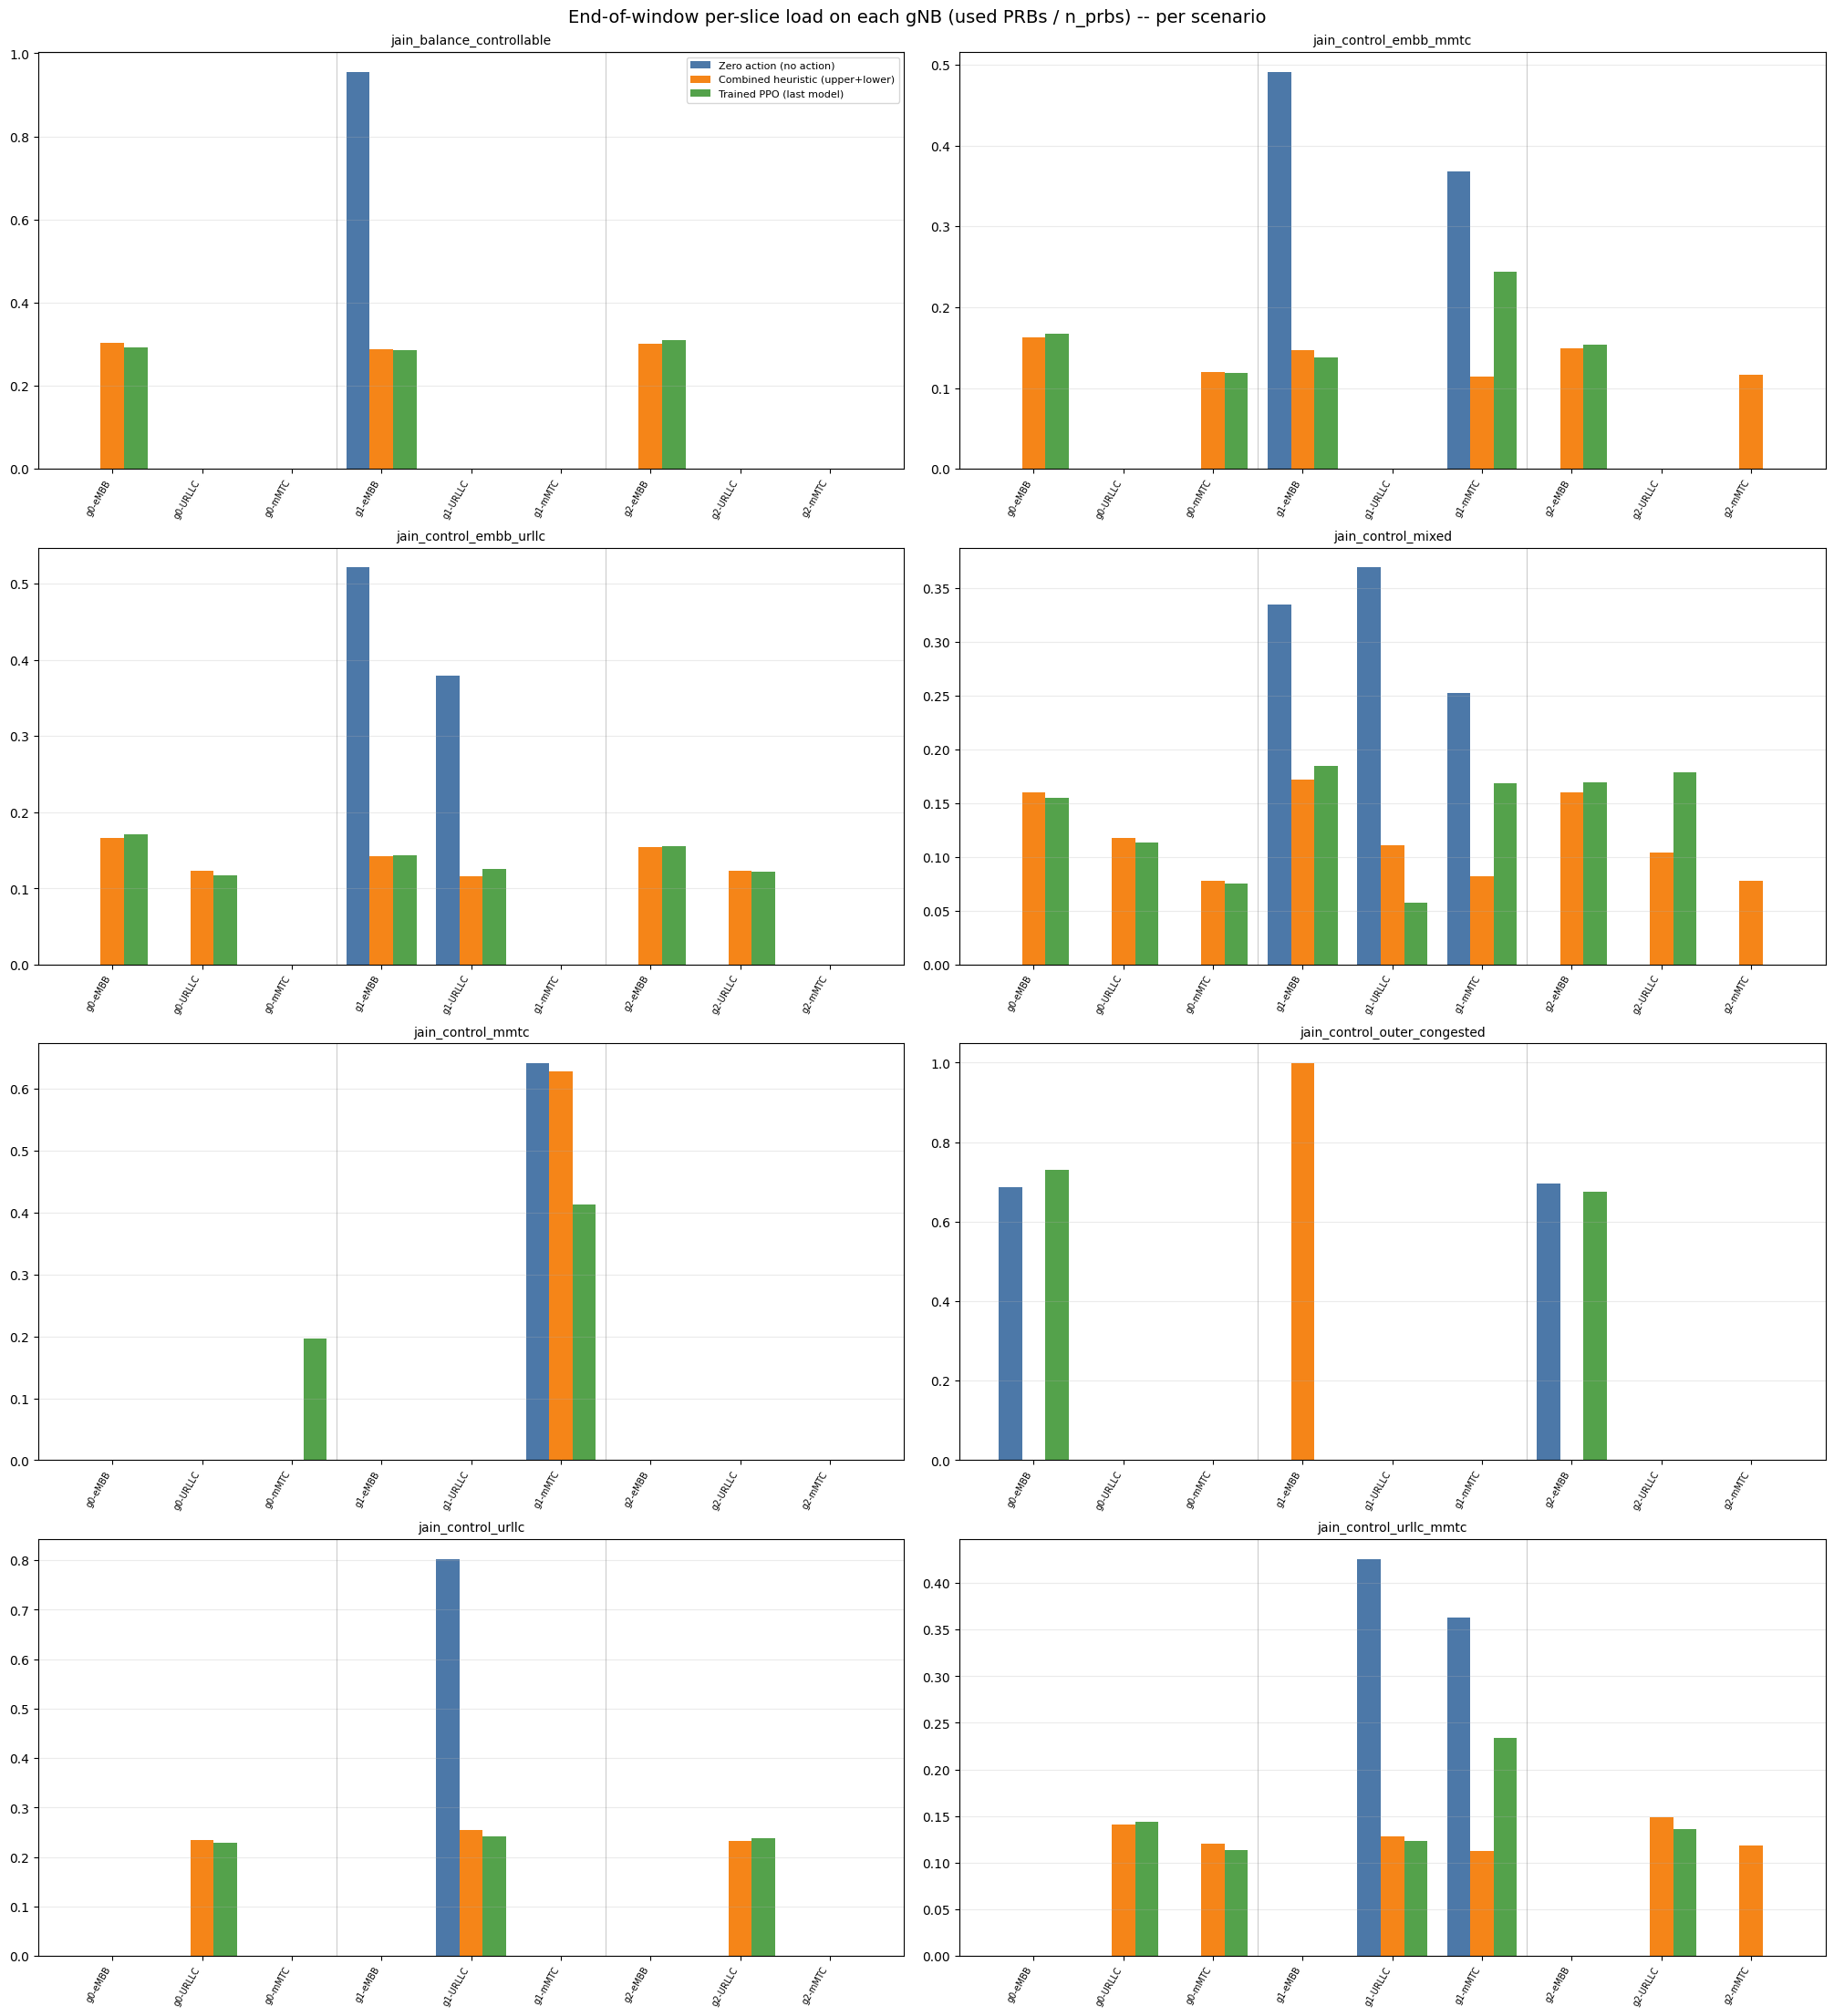

In [10]:
N_PRBS = 100.0  # per-gNB PRB budget (matches env default; load = used_prb / n_prbs)

per_gnb_slice_cols, gnb_slice_labels = [], []
for g in GNBS:
    for s in SLICES:
        col = f'used_prb_end_g{g}_{s}'
        if col in trace.columns:
            per_gnb_slice_cols.append(col)
            gnb_slice_labels.append(f'g{g}-{s}')

slice_load = trace[['scenario_name', 'controller'] + per_gnb_slice_cols].copy()
load_cols = [c + '_load' for c in per_gnb_slice_cols]
for raw_col, load_col in zip(per_gnb_slice_cols, load_cols):
    slice_load[load_col] = slice_load[raw_col] / N_PRBS

per_gnb_slice_summary = slice_load.groupby(['scenario_name', 'controller'])[load_cols].mean().reset_index()
per_gnb_slice_summary.to_csv(OUT_DIR / 'per_gnb_per_slice_load_summary.csv', index=False)

fig, axes = plt.subplots(4, 2, figsize=(20, 22), constrained_layout=True)
axes = axes.ravel()
x = np.arange(len(gnb_slice_labels))
width = 0.26
for ax, scenario in zip(axes, SCENARIOS):
    sub = per_gnb_slice_summary[per_gnb_slice_summary['scenario_name'] == scenario]
    for i, controller in enumerate(CONTROLLER_ORDER):
        row = sub[sub['controller'] == controller]
        vals = [float(row[c].iloc[0]) if len(row) else np.nan for c in load_cols]
        ax.bar(x + (i - 1) * width, vals, width, label=controller, color=CONTROLLER_COLORS[controller])
    for boundary in (2.5, 5.5):
        ax.axvline(boundary, color='grey', lw=0.8, alpha=0.4)
    ax.set_title(scenario, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(gnb_slice_labels, rotation=60, ha='right', fontsize=7)
    ax.grid(axis='y', alpha=0.25)
for ax in axes[len(SCENARIOS):]:
    ax.axis('off')
axes[0].legend(fontsize=8)
fig.suptitle('End-of-window per-slice load on each gNB (used PRBs / n_prbs) -- per scenario', fontsize=14)
out_path = OUT_DIR / 'per_gnb_per_slice_load_all_scenarios.png'
plt.savefig(out_path, dpi=160, bbox_inches='tight')
print('Saved:', out_path)
plt.show()

## 8. Per-slice QoS -- averaged across all scenarios

,controller,slice_type,throughput_mbps,delivery_ratio,mean_hol_delay_ms,sinr_db
0,Combined heuristic (upper+lower),URLLC,15.262,1.000,0.100,12.538
1,Combined heuristic (upper+lower),eMBB,39.713,0.997,12.196,13.616
2,Combined heuristic (upper+lower),mMTC,15.856,1.000,0.087,10.410
3,Trained PPO (last model),URLLC,15.377,1.000,0.196,12.493
4,Trained PPO (last model),eMBB,38.442,1.000,0.087,14.515
5,Trained PPO (last model),mMTC,16.248,1.000,0.081,8.178
6,Zero action (no action),URLLC,11.271,1.000,0.456,3.979
7,Zero action (no action),eMBB,28.805,0.990,29.475,5.933
8,Zero action (no action),mMTC,12.529,1.000,0.060,3.991


Saved: results/last_model_comparison/per_slice_qos_all_scenarios.png


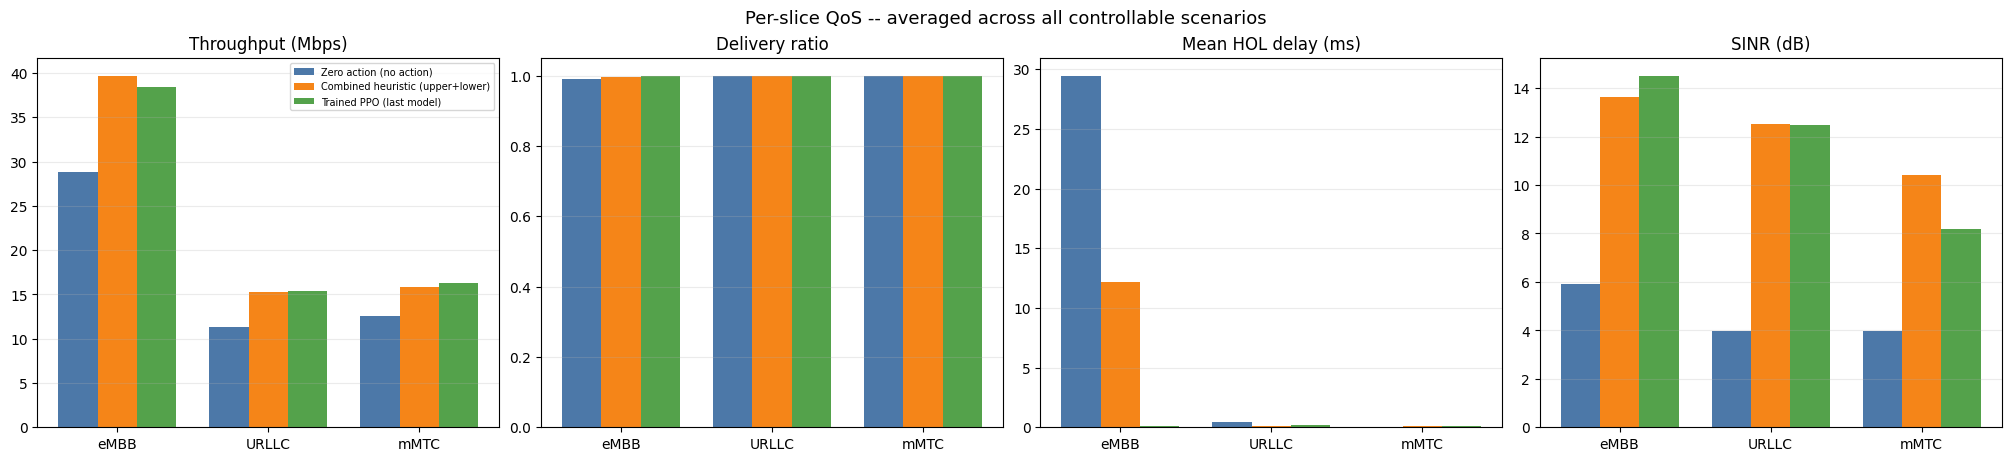

In [11]:
slice_qos_rows = []
for _, row in trace.iterrows():
    for slice_type in SLICES:
        slice_qos_rows.append({
            'controller': row['controller'],
            'scenario_name': row['scenario_name'],
            'slice_type': slice_type,
            'throughput_mbps': row.get(f'qos_slice_throughput_mbps_{slice_type}', np.nan),
            'delivery_ratio': row.get(f'qos_slice_delivery_ratio_{slice_type}', np.nan),
            'mean_hol_delay_ms': row.get(f'qos_slice_mean_hol_delay_ms_{slice_type}', np.nan),
            'sinr_db': row.get(f'qos_slice_sinr_db_{slice_type}', np.nan),
        })
slice_qos = pd.DataFrame(slice_qos_rows)
slice_qos_summary = slice_qos.groupby(['controller', 'slice_type'], as_index=False).mean(numeric_only=True)
slice_qos_summary.to_csv(OUT_DIR / 'qos_per_slice_summary_all_scenarios.csv', index=False)
display(slice_qos_summary.round(3))

qos_metrics = [
    ('throughput_mbps', 'Throughput (Mbps)', None),
    ('delivery_ratio', 'Delivery ratio', (0, 1.05)),
    ('mean_hol_delay_ms', 'Mean HOL delay (ms)', None),
    ('sinr_db', 'SINR (dB)', None),
]
x = np.arange(len(SLICES))
width = 0.26
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), constrained_layout=True)
for ax, (metric, title, ylim) in zip(axes, qos_metrics):
    for i, controller in enumerate(CONTROLLER_ORDER):
        vals = []
        for slice_type in SLICES:
            row = slice_qos_summary[(slice_qos_summary['controller'] == controller) & (slice_qos_summary['slice_type'] == slice_type)]
            vals.append(float(row[metric].iloc[0]) if len(row) else np.nan)
        ax.bar(x + (i - 1) * width, vals, width, label=controller, color=CONTROLLER_COLORS[controller])
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(SLICES)
    ax.grid(axis='y', alpha=0.25)
    if ylim is not None:
        ax.set_ylim(*ylim)
axes[0].legend(fontsize=7)
fig.suptitle('Per-slice QoS -- averaged across all controllable scenarios', fontsize=13)
out_path = OUT_DIR / 'per_slice_qos_all_scenarios.png'
plt.savefig(out_path, dpi=160, bbox_inches='tight')
print('Saved:', out_path)
plt.show()

## 9. Deep-dive on the model's actual training scenario (`jain_control_mixed`)

,scenario_name,controller,reward,handover_count,network_throughput_mbps,network_delivery_ratio,jain_fairness_raw,sla_severity,sla_count,paper_demand_load_std,paper_excess_load_mean,network_mean_hol_delay_ms,network_queue_kbits,network_drop_ratio
9,jain_control_mixed,Combined heuristic (upper+lower),-0.6667,12.0,98.8305,0.9999,0.9969,0.0000,0.0,0.0000,0.0000,0.0722,11.5136,0.0
10,jain_control_mixed,Trained PPO (last model),0.0846,11.0,105.6084,0.9999,0.9916,0.0003,0.1,0.0245,0.0000,0.1167,13.6269,0.0
11,jain_control_mixed,Zero action (no action),-1.0985,0.0,54.8802,0.8784,0.3333,0.0351,1.7,0.4243,0.0833,77.2278,7614.5613,0.0


Saved: results/last_model_comparison/jain_control_mixed_per_slice_qos_traincheck.png


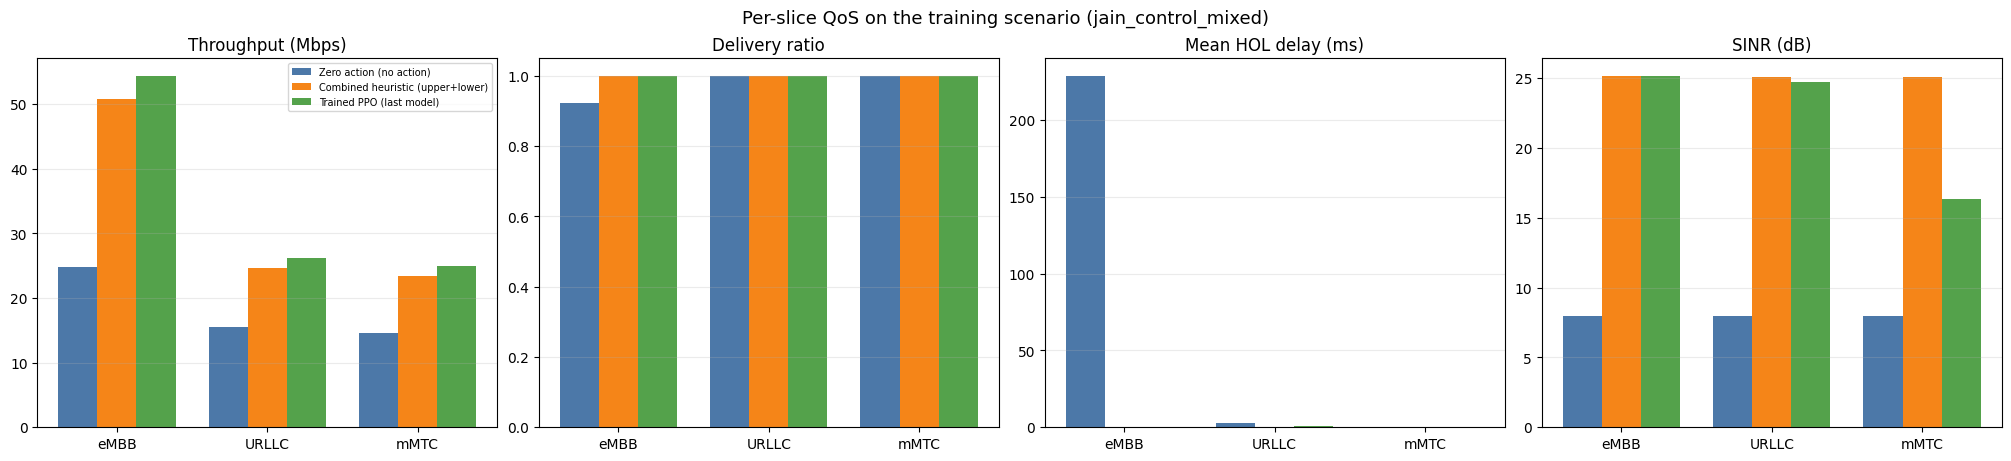

In [12]:
TRAIN_SCENARIO = config.get('single_training_scenario', 'jain_control_mixed')
sub_summary = scenario_summary[scenario_summary['scenario_name'] == TRAIN_SCENARIO]
display(sub_summary.round(4))

sub_slice = slice_qos[slice_qos['scenario_name'] == TRAIN_SCENARIO].groupby(['controller', 'slice_type'], as_index=False).mean(numeric_only=True)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), constrained_layout=True)
for ax, (metric, title, ylim) in zip(axes, qos_metrics):
    for i, controller in enumerate(CONTROLLER_ORDER):
        vals = []
        for slice_type in SLICES:
            row = sub_slice[(sub_slice['controller'] == controller) & (sub_slice['slice_type'] == slice_type)]
            vals.append(float(row[metric].iloc[0]) if len(row) else np.nan)
        ax.bar(x + (i - 1) * width, vals, width, label=controller, color=CONTROLLER_COLORS[controller])
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(SLICES)
    ax.grid(axis='y', alpha=0.25)
    if ylim is not None:
        ax.set_ylim(*ylim)
axes[0].legend(fontsize=7)
fig.suptitle(f'Per-slice QoS on the training scenario ({TRAIN_SCENARIO})', fontsize=13)
out_path = OUT_DIR / f'{TRAIN_SCENARIO}_per_slice_qos_traincheck.png'
plt.savefig(out_path, dpi=160, bbox_inches='tight')
print('Saved:', out_path)
plt.show()

## 10. Takeaways

In [13]:
print(f'Model: {MODEL_PATH}')
print(f'Trained on: {TRAIN_SCENARIO} only, {config.get("total_timesteps")} timesteps')
print()
print(f'Across all {len(SCENARIOS)} controllable scenarios and {len(check_metrics)} QoS/load metrics:')
print(f'  PPO between zero-action and combined heuristic: {share:.0%} of cases')
print()
on_train = between_df[between_df['scenario'] == TRAIN_SCENARIO]['ppo_between_zero_and_heuristic'].mean()
off_train = between_df[between_df['scenario'] != TRAIN_SCENARIO]['ppo_between_zero_and_heuristic'].mean()
print(f'  On its training scenario ({TRAIN_SCENARIO}): {on_train:.0%}')
print(f'  On the other {len(SCENARIOS) - 1} unseen scenarios: {off_train:.0%}')
print()
print('All artifacts (CSVs + PNGs) saved under:', OUT_DIR)

Model: models/upper_ppo_mixed_only_fixed_reward_10k/run_20260706_212506/upper_ppo_final.zip
Trained on: jain_control_mixed only, 10000 timesteps

Across all 8 controllable scenarios and 6 QoS/load metrics:
  PPO between zero-action and combined heuristic: 71% of cases

  On its training scenario (jain_control_mixed): 83%
  On the other 7 unseen scenarios: 69%

All artifacts (CSVs + PNGs) saved under: results/last_model_comparison
